# Estimation du champ de mouvement par Lucas-Kanade

## Description

Lucas-Kanade estime le flot optique entre deux frames successives. Les points suivis sur la voiture produisent des vecteurs de deplacement, et ces vecteurs representent le champ de mouvement demande. La methode suppose de petits deplacements, une illumination localement constante, une coherence spatiale et un objet globalement rigide.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)


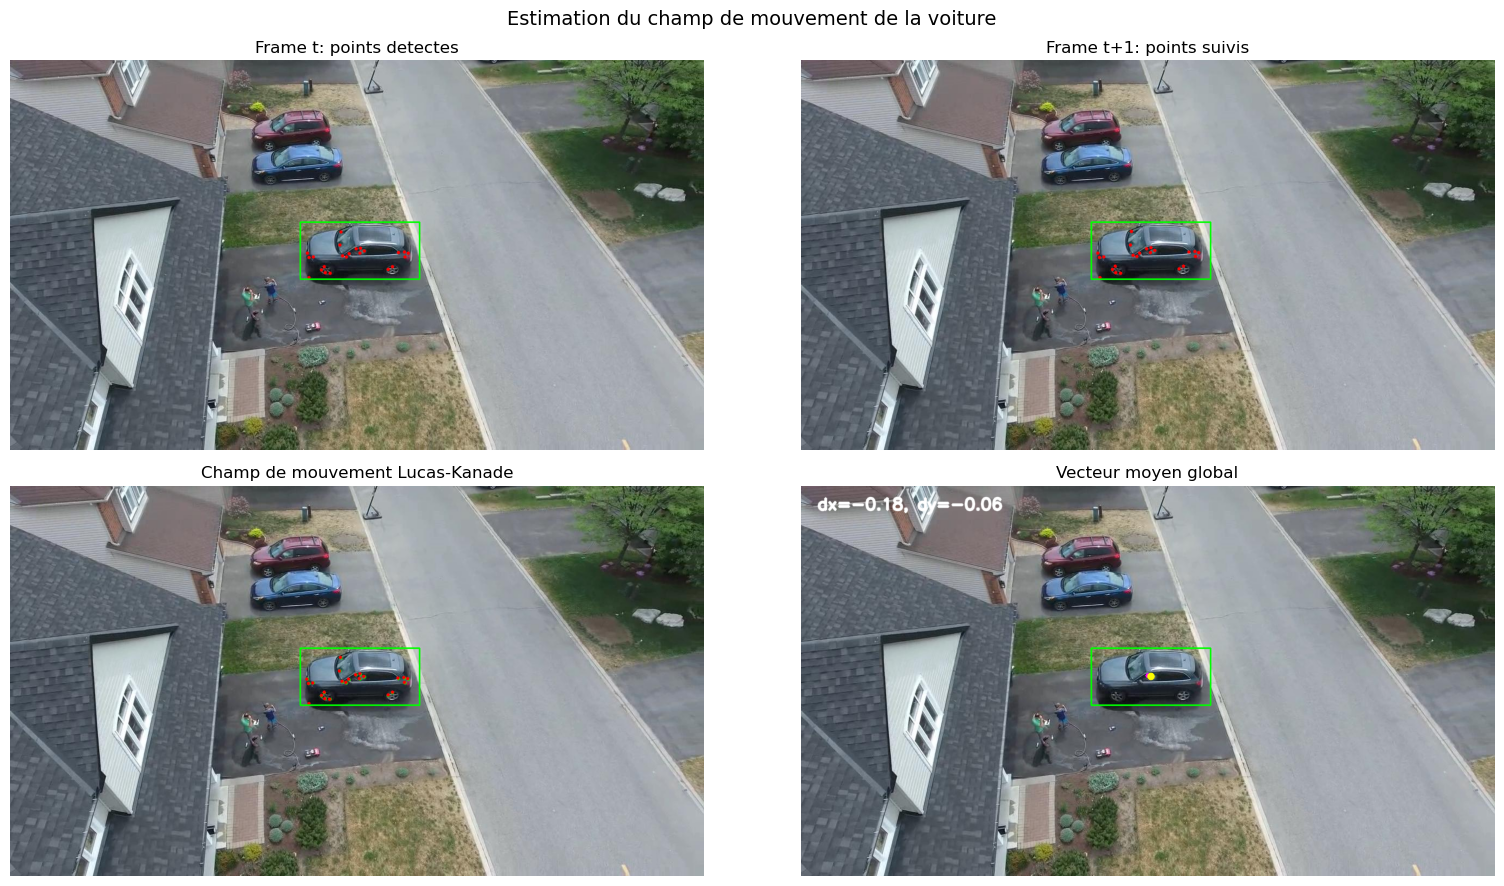

Nombre de points suivis: 23
dx_global: -0.17870032787322998
dy_global: -0.05713554099202156


In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # bbox manuelle: x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def draw_bbox_local(image, bbox, color=(0, 255, 0), thickness=2):
    out = image.copy()
    x, y, w, h = [int(v) for v in bbox]
    cv2.rectangle(out, (x, y), (x + w, y + h), color, thickness)
    return out

def draw_points_local(image, points, color=(0, 0, 255)):
    out = image.copy()
    if points is None:
        return out
    for px, py in np.asarray(points).reshape(-1, 2):
        cv2.circle(out, (int(px), int(py)), 3, color, -1)
    return out

def draw_mask_overlay_local(frame, mask, bbox):
    out = frame.copy()
    overlay = out.copy()
    x, y, w, h = [int(v) for v in bbox]
    mask_roi = mask
    if mask_roi.shape[:2] != (h, w):
        mask_roi = cv2.resize(mask_roi, (w, h), interpolation=cv2.INTER_NEAREST)
    roi = overlay[y:y+h, x:x+w]
    roi[mask_roi > 0] = (0, 255, 0)
    overlay[y:y+h, x:x+w] = roi
    return cv2.addWeighted(overlay, 0.35, out, 0.65, 0)

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

from src.preprocessing import preprocess_image_with_method
from src.detection import segment_and_clean_car, detect_features_in_roi, filter_features_by_mask
from src.optical_flow import estimate_motion_field, draw_optical_flow_vectors

flow_dir = ensure_dir(RESULTS_DIR / "optical_flow")
frame_t = cv2.imread(str(image_files[0]))
frame_tp1 = cv2.imread(str(image_files[1]))
gray_t = preprocess_image_with_method(frame_t, method="stretching")["enhanced"]
gray_tp1 = preprocess_image_with_method(frame_tp1, method="stretching")["enhanced"]
seg = segment_and_clean_car(gray_t, initial_bbox, method="otsu", invert=True)
mask = seg["largest_component"]
points = detect_features_in_roi(gray_t, initial_bbox)
masked_points = filter_features_by_mask(points, initial_bbox, mask)
if masked_points is not None and len(masked_points) >= 5:
    points = masked_points
field = estimate_motion_field(gray_t, gray_tp1, points)

points_img = draw_bbox_local(draw_points_local(frame_t, points), initial_bbox)
tracked_img = draw_bbox_local(draw_points_local(frame_tp1, field["good_new"]), initial_bbox)
vectors_img = draw_optical_flow_vectors(frame_tp1, field["good_old"], field["good_new"])
vectors_img = draw_bbox_local(vectors_img, initial_bbox)

mean_img = draw_bbox_local(frame_tp1, initial_bbox)
x, y, w, h = initial_bbox
center = (int(x + w / 2), int(y + h / 2))
scale = 35
end = (int(center[0] + field["dx_global"] * scale), int(center[1] + field["dy_global"] * scale))
cv2.arrowedLine(mean_img, center, end, (255, 0, 255), 5, tipLength=0.25)
cv2.circle(mean_img, center, 7, (0, 255, 255), -1)
cv2.putText(mean_img, f"dx={field['dx_global']:.2f}, dy={field['dy_global']:.2f}", (30, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3, cv2.LINE_AA)

save_bgr(flow_dir / "frame_t_points.png", points_img)
save_bgr(flow_dir / "frame_t_plus_1_tracked_points.png", tracked_img)
save_bgr(flow_dir / "lucas_kanade_vectors.png", vectors_img)
save_bgr(flow_dir / "global_mean_vector.png", mean_img)
save_bgr(RESULTS_DIR / "final_visualization" / "representative_motion_field_lk.png", vectors_img)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
items = [("Frame t: points detectes", points_img), ("Frame t+1: points suivis", tracked_img), ("Champ de mouvement Lucas-Kanade", vectors_img), ("Vecteur moyen global", mean_img)]
for ax, (title, image) in zip(axes.ravel(), items):
    ax.imshow(bgr_to_rgb(image))
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("Estimation du champ de mouvement de la voiture", fontsize=14)
fig.tight_layout()
fig.savefig(flow_dir / "optical_flow_grid.png", dpi=150)
plt.show()

print("Nombre de points suivis:", field["num_points"])
print("dx_global:", field["dx_global"])
print("dy_global:", field["dy_global"])


## Interpretation

Les vecteurs Lucas-Kanade representent le deplacement local des points suivis sur la voiture entre deux frames successives. Le vecteur moyen synthetise le mouvement global de l'objet rigide. Si les vecteurs sont coherents et restent situes sur la voiture, le champ de mouvement est satisfaisant. Les limites possibles sont la perte de points, une texture faible, un mouvement trop grand ou un changement d'eclairage.


## Resume de l'etape

Le champ de mouvement a ete estime par Lucas-Kanade et visualise sous forme de vecteurs. Cette estimation sert ensuite a mettre a jour la position de la voiture et a construire sa trajectoire globale.
